# **Системные требования**

Перед началом работы убедитесь, что ваш компьютер или сервер соответствует минимальным требованиям для запуска модели Llama 3 8B в 4-битном режиме:

•	**Операционный процессор (CPU):** современный многоядерный процессор x86_64. CPU задействуется при загрузке модели и обслуживании API, но основная нагрузка будет на GPU.

•	**Оперативная память (RAM):** не менее 16 ГБ. Часть памяти потребуется для загрузки модели и работы сопровождающих сервисов.

•	**Видеокарта (GPU):** современный дискретный GPU с поддержкой CUDA. Рекомендуется уровень NVIDIA Tesla T4 (16 ГБ VRAM) или выше. Модель Llama 3 8B 4-bit занимает ~4–6 ГБ видеопамяти, поэтому запустится даже на относительно слабых GPU. Однако для комфортной работы лучше иметь запас VRAM (>= 8 ГБ).

•	**Дисковое пространство:** не менее 20 ГБ свободно. Около 15–16 ГБ понадобится для хранения файлов модели (скачиваемых из Hugging Face), плюс место для контейнеров Docker и кеша.

**Примечание:** Если у вас нет подходящего GPU, запуск модели возможен только на CPU, но будет очень медленным. Наличие CUDA-совместимого GPU значительно ускорит генерацию ответов модели.


Для нашей демонстрации мы арендовали выделенный сервер в компании Selectel следующей конфигурации:

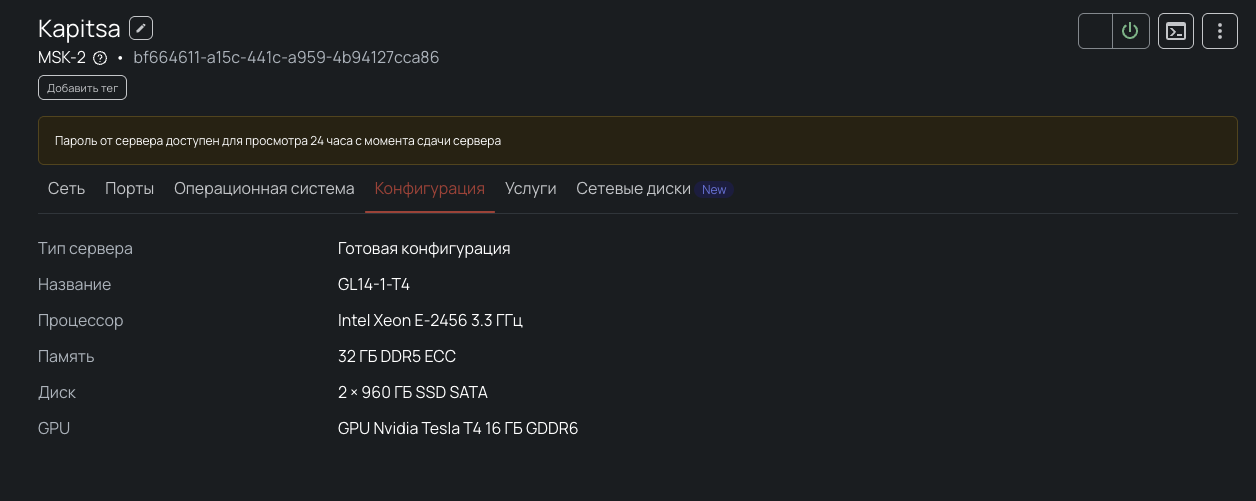

## **Firewall/безопасность:**

 Если сервер находится, например, в облаке (AWS, Cloud.ru и т.д.), убедитесь, что на уровне облака открыты соответствующие порты (Security Groups, Firewall rules). Локально на Ubuntu, если настроен UFW, нужно разрешить порт 8000 (или 80):

In [ ]:
sudo ufw allow 8000/tcp

(Если сервис планируется поднимать на 80, то sudo ufw allow 80/tcp и.т.д.) И соответсвенно повторить для каждого нужного порта.

### **Устанавливаем то, что считаем необходимым**

In [ ]:
apt install -y mc tmux

# **Установка драйверов NVIDIA и Docker**

Для запуска LLM-модели на GPU требуется правильно настроить систему: установить драйверы NVIDIA, систему контейнеризации Docker и специальный NVIDIA Toolkit для Docker. Ниже приведены подробные шаги, адаптированные из официальной инструкции.

Но первым делом мы должны обновить систему! Это первое, что должен сделать пользователь попав в новую среду Linux. Причем даже если вы ее только что установили.

In [ ]:
sudo apt -y update && sudo apt -y upgrade

# **Обновляем Python до версии 3.13**

В Ubuntu 24.04 LTS по умолчанию установлен Python 3.12  и хотя это не имеет критической важности для нашего проекта но в требованиях указан Python 3.13. Обновим его.

In [ ]:
add-apt-repository ppa:deadsnakes/ppa
apt install -y python3.13 python3.13-venv python3.13-dev

## **Удаление старых драйверов NVIDIA**

Если на системе ранее устанавливались драйверы NVIDIA, рекомендуется удалить их, чтобы избежать конфликтов версий.

Выполните команду удаления всех пакетов NVIDIA и очистите зависимости:

In [ ]:
sudo apt-get purge 'nvidia-*'
sudo apt-get update
sudo apt-get autoremove

Первая команда purge удалит все пакеты, имена которых начинаются с nvidia-, включая старые драйверы и библиотеки. Затем apt-get autoremove очистит ненужные зависимости. После запуска этих команд система может удалить много пакетов – это нормально.

## **Установка драйвера NVIDIA**

Теперь установим свежий драйвер NVIDIA. На момент конца 2025 года актуальной версией для новых GPU является серия 580 (например, nvidia-driver-580-open). Вы можете удостовериться, какие версии драйверов доступны, выполнив поиск:

In [ ]:
apt search nvidia-driver

Для установки рекомендуется последняя версия драйвера, совместимая с вашей видеокартой. Например, для серии RTX 50xx нужно установить пакет nvidia-driver-570-open. Выполните команду (замените номер версии при необходимости):

In [ ]:
sudo apt install -y nvidia-driver-580-open

Этот пакет установит драйвер NVIDIA и связанные с ним компоненты. Ключ -y автоматически согласится со всеми запросами при установке. После успешной установки драйвера в системе появятся необходимые модули ядра NVIDIA.

## **Перезагрузка и проверка GPU**

Перезагрузим сервер командой:

In [ ]:
sudo reboot

Перезагрузка необходима, чтобы загрузить новый модуль драйвера в ядро. После перезапуска проверьте, распознаётся ли GPU, командой nvidia-smi. Эта утилита выводит информацию о подключённых NVIDIA GPU и версии драйвера:

In [ ]:
nvidia-smi

Если драйвер установлен корректно, вы увидите таблицу с названием вашей видеокарты, версией драйвера и статистикой памяти.
Это будет выглядеть как то так:

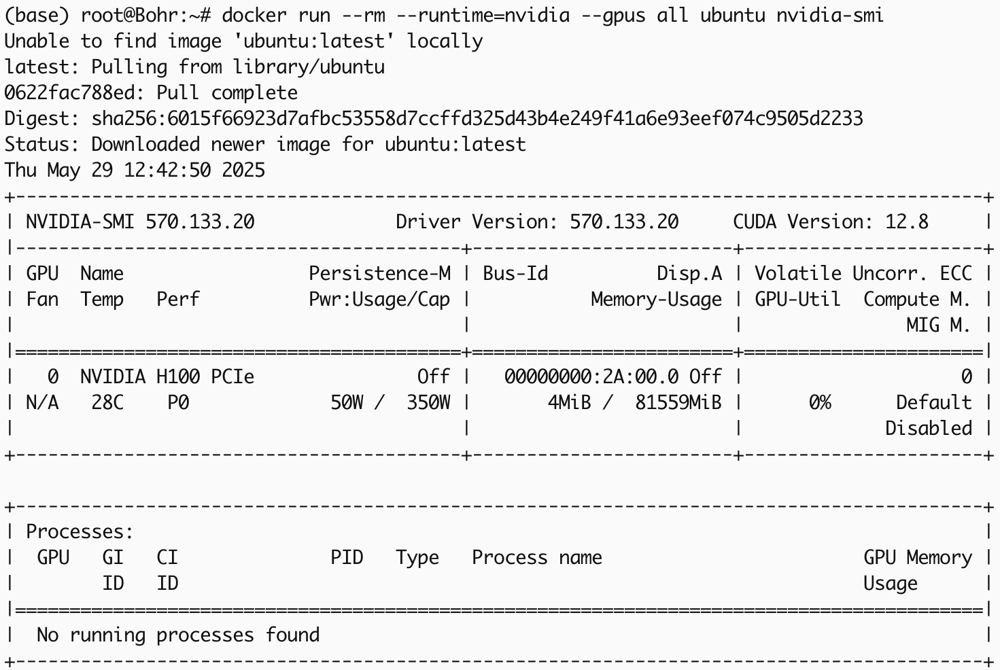![image.png]()

Обратите внимание на столбцы **GPU, Name, Memory-Usage** – здесь должна отображаться ваша модель видеокарты и объём использованной памяти.

**Если вместо таблицы выводится ошибка или утилита отсутствует, значит драйвер не установился.**

В таком случае:

•	Убедитесь, что в BIOS отключён Secure Boot (он может блокировать загрузку модулей NVIDIA).

•	Проверьте логи установки на ошибки.

•	При необходимости попробуйте установить другую версию драйвера, повторив шаги очистки и установки заново.


## **Установка Docker и Docker Compose**

Docker позволит упаковать наше приложение и модель в контейнер, а также запустить сопутствующие сервисы (например, мониторинг) изолированно. Сначала установим сам Docker Engine и утилиту Compose.

 Выполните следующие шаги (для Ubuntu 22.04/24.04):

Перед установкой Docker необходимо удалить возможные конфликтующие старые пакеты и их зависимости.

In [ ]:
sudo apt-get remove -y docker docker-engine docker.io containerd runc docker-compose || true
sudo apt-get autoremove -y || true

### **1.	Добавление репозитория Docker:**

Docker предоставляется в собственном репозитории. Добавим ключ GPG и сам репозиторий:

In [ ]:
sudo apt update && sudo apt install -y ca-certificates curl gnupg
sudo install -m 0755 -d /etc/apt/keyrings
curl -fsSL https://download.docker.com/linux/ubuntu/gpg | sudo gpg --dearmor -o /etc/apt/keyrings/docker.gpg
sudo chmod a+r /etc/apt/keyrings/docker.gpg
echo "deb [arch=$(dpkg --print-architecture) signed-by=/etc/apt/keyrings/docker.gpg] \
  https://download.docker.com/linux/ubuntu $(. /etc/os-release && echo "$VERSION_CODENAME") stable" | \
  sudo tee /etc/apt/sources.list.d/docker.list > /dev/null

Первая команда установит необходимые пакеты (curl, gnupg и др.) для добавления репозитория. Затем с помощью curl и gpg мы добавляем официальный GPG-ключ Docker и сохраняем его. Последняя команда добавляет URL репозитория Docker в систему (в файл /etc/apt/sources.list.d/docker.list).

### **2. Установка Docker Engine: **

После добавления репозитория выполните:

In [ ]:
sudo apt update
sudo apt install -y docker-ce docker-ce-cli containerd.io docker-buildx-plugin docker-compose-plugin

Эти пакеты установят сервис Docker (docker-ce), клиентские утилиты, а также плагин Compose. Флаг -y автоматически подтвердит установку.

### **3. Проверка установки: **

Убедитесь, что Docker установлен и работает:

In [ ]:
docker --version
docker compose version

Первая команда выведет версию Docker Engine, вторая – версию плагина Docker Compose. Например, вы должны увидеть что-то вроде Docker version 24.0.5 ... и Docker Compose version v2.17.3 (номера могут отличаться).

Docker теперь установлен как демон (служба docker уже должна запуститься автоматически). Вы можете проверить статус сервиса командой sudo systemctl status docker (ожидается состояние active (running)).

## **Установка NVIDIA Container Toolkit**

Для того чтобы контейнеры Docker могли использовать GPU, необходимо установить NVIDIA Container Toolkit (ранее известный как nvidia-docker2). Этот инструмент позволяет пробросить CUDA-драйверы и библиотеки внутрь контейнера.

Установка выполняется через пакетный менеджер apt:

In [ ]:
curl -fsSL https://nvidia.github.io/libnvidia-container/gpgkey | sudo gpg --dearmor -o /usr/share/keyrings/nvidia-container-toolkit-keyring.gpg

curl -s -L https://nvidia.github.io/libnvidia-container/stable/deb/nvidia-container-toolkit.list | \
  sed 's#deb https://#deb [signed-by=/usr/share/keyrings/nvidia-container-toolkit-keyring.gpg] https://#g' | \
  sudo tee /etc/apt/sources.list.d/nvidia-container-toolkit.list

sudo apt-get update
sudo apt-get install -y nvidia-container-toolkit

Первая команда добавляет GPG-ключ NVIDIA Container Toolkit (чтобы apt доверял пакетам). Вторая – добавляет соответствующий репозиторий. Последние две устанавливают пакет nvidia-container-toolkit. После установки toolkit предоставляет специальный контейнерный рантайм для Docker.

## **Настройка Docker для работы с GPU**

После установки Toolkit нужно настроить Docker, чтобы он по умолчанию использовал NVIDIA Runtime для контейнеров с GPU.

Для этого выполните команду конфигурации:

In [ ]:
sudo nvidia-ctk runtime configure --runtime=docker
sudo systemctl restart docker

Первая команда автоматически пропишет необходимые настройки Docker (добавит runtime "nvidia" в конфиг Docker).

Вторая перезапускает сервис Docker, чтобы изменения вступили в силу.

Теперь Docker готов запускать контейнеры с использованием GPU.

## **Проверка доступа к GPU внутри контейнера**

Проверим, что установленный Toolkit работает корректно. Запустим тестовый контейнер Ubuntu с доступом к GPU и выполним внутри него nvidia-smi:

In [ ]:
sudo docker run --rm --runtime=nvidia --gpus all ubuntu:latest nvidia-smi

Разберём эту команду:

docker run --rm запускает новый контейнер (с автоматическим удалением --rm после завершения).

Параметр --runtime=nvidia указывает Docker использовать NVIDIA Container Runtime для этого контейнера.

--gpus all запрашивает проброс всех доступных GPU в контейнер.

Образ ubuntu:latest – это официальный минимальный образ Ubuntu.

Наконец, nvidia-smi – команда, которую мы хотим выполнить внутри контейнера.

Если всё настроено правильно, внутри контейнера выполнится nvidia-smi и вы увидите тот же вывод, что и на хосте (информация о вашей видеокарте):

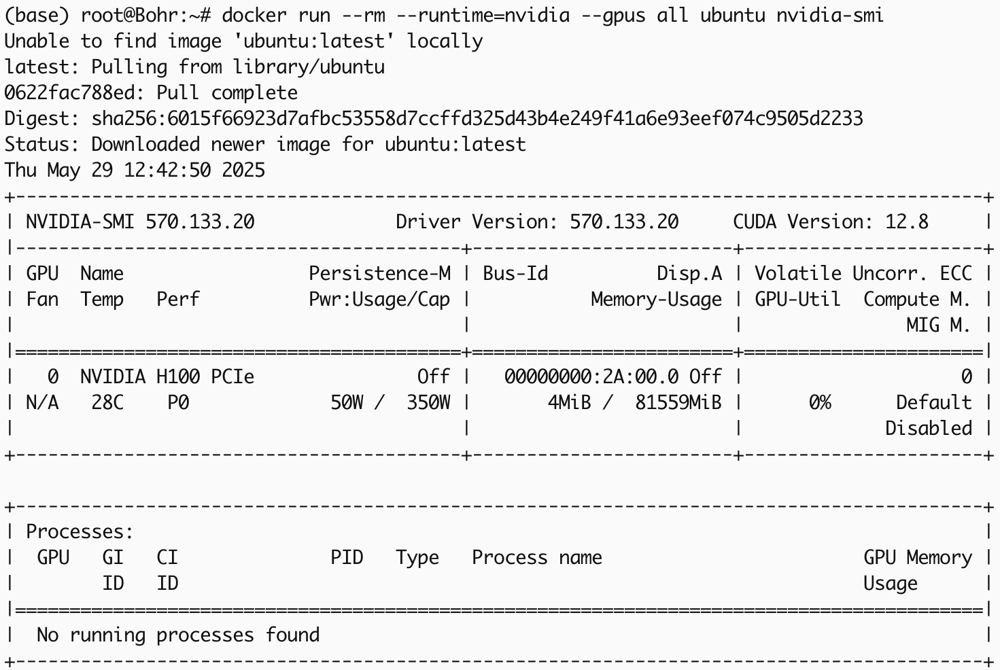

Вывод nvidia-smi из контейнера подтверждает, что Docker видит GPU через установленный toolkit. На этом настройка системы завершена: у нас установлены драйверы NVIDIA и Docker с возможностью использовать GPU внутри контейнеров.

# **Пошаговый запуск LLM-модели**

Теперь перейдём непосредственно к запуску Large Language Model (LLM) – Llama 3 8B (Instruct), квантованной до 4 бит. Мы рассмотрим несколько способов запуска:

Запуск FastAPI-приложения вручную (на хосте): используем готовый код приложения (FastAPI) для развертывания модели как веб-сервиса.

Запуск модели в Docker через Ollama: альтернативный способ без написания кода – с помощью утилиты Ollama, которая управляет LLM-моделями.

Запуск модели в Docker через llama.cpp: запуск через лёгкий C++ сервер (llama.cpp) с OpenAI-совместимым API.

Мониторинг сервиса: подключение Prometheus и Grafana для сбора метрик работы модели и построения графиков.

Мы подробно пройдём все шаги – от подготовки проекта до отправки тестовых запросов. Все команды будут сопровождаться объяснениями (что делаем и зачем), чтобы даже новичок понял процесс.

## **Запуск FastAPI-приложения (вручную)**

Первый способ – запустить наше приложение на базе FastAPI напрямую на хосте. Это подойдёт для отладки и понимания работы модели. Приложение предоставит REST API для генерации ответов LLM и простую веб-страницу для взаимодействия.

Шаг 1: Получение кода проекта. Код приложения расположен в архиве/репозитории Simple_bot-main. Получите этот код на сервер. Если у вас есть файл ZIP – скопируйте его на сервер и распакуйте. Либо клонируйте репозиторий через git, например:

In [ ]:
git clone https://github.com/SoldatovAlexander/Simple_bot.git
cd Simple_bot

После этого в каталоге Simple_bot вы увидите файлы проекта. Структура проекта следующая:

app.py – основной файл приложения FastAPI. Здесь определены REST endpoints, запуск модели и HTML-страница для тестирования.

model.py – логика загрузки модели и генерации ответа. Загружает модель Llama 3 8B (4-bit).

requirements.txt – список необходимых Python-зависимостей (FastAPI, Transformers, BitsAndBytes и др.).

Dockerfile – инструкция для сборки Docker-образа с нашим приложением (на базе Ubuntu 24.04 + CUDA).

docker-compose.yml – описание контейнеров для приложения, мониторинга Prometheus/Grafana и экспортера метрик GPU.

Папки prometheus/ и grafana/ – настройки для мониторинга (конфигурация Prometheus, дашборды Grafana).


### **Что мы запускаем и зачем**

**Simple_bot** — это минимальный сервис на FastAPI, который:
загружает open‑source модель Llama 3 8B Instruct (4‑bit) из Hugging Face (по умолчанию unsloth/llama-3-8b-Instruct-bnb-4bit);

отдаёт HTTP‑эндпоинт POST /generate для генерации текста;

имеет простую HTML‑страницу GET / для ручной проверки;

отдаёт «здоровье» GET /health (включая подсказки по CUDA/драйверу/bitsandbytes);

отдаёт метрики Prometheus на /metrics (экспортируется автоматически инструментатором).

Важно про упрощение:

в проекте нет обучения и нет LoRA/QLoRA (никаких наложений адаптеров);

модель используется только для inference.

Проект читает переменные окружения через python-dotenv

Главные переменные

* BASE_MODEL_NAME — имя модели на Hugging Face.

дефолт: unsloth/llama-3-8b-Instruct-bnb-4bit

* SYSTEM_PROMPT — «роль» ассистента (системная инструкция). Если не задана — используется дефолтная строка.

* DEFAULT_MAX_NEW_TOKENS — лимит токенов по умолчанию (дефолт 180).

* DEFAULT_TEMPERATURE — температура по умолчанию (дефолт 0.7).

* LOG_LEVEL — уровень логов (дефолт WARNING).



Создаем и вводим переменные окружения

In [ ]:
cp .env.example .env

### **Создаем и активируем виртуальное окружение, так же обновляем дополнительные пакеты.**

In [ ]:
python3.13 -m venv .venv && source .venv/bin/activate
pip install --upgrade pip
python -m pip install -U pip setuptools wheel

### **Ставим зависимости**

In [ ]:
pip install -r requirements.txt

### **Запускаем uvicorn**

In [ ]:
uvicorn app:app --host 0.0.0.0 --port 8000

### **Проверяем работу**

Swagger и API

Открыть:

In [ ]:
http://212.41.7.122:8000/ (HTML)
http://212.41.7.122:8000/docs (Swagger)
http://212.41.7.122:8000/metrics (Prometheus)

## **Запуск модели через Docker (Ollama)**

Альтернативный способ поработать с Llama 3 – использовать Ollama. Это инструмент, позволяющий легко загружать и локально запускать различные языковые модели, упакованные со своими параметрами. Ollama предоставляет как CLI, так и REST API для взаимодействия с моделями. Мы воспользуемся официальным Docker-образом Ollama, чтобы не устанавливать ничего лишнего на систему. Запуск производится за несколько шагов.

### **Шаг 1: Загрузка Docker-образа Ollama.**

Убедитесь, что Docker настроен на использование GPU (мы сделали это в разделе при подготовке системы). Теперь выполните команду запуска контейнера Ollama:

In [ ]:
docker run -d --gpus=all -v ollama:/root/.ollama -p 11434:11434 --name ollama ollama/ollama:latest

Поясним аргументы:

docker run -d запускает контейнер в фоновом режиме (detached).

--gpus=all – пробрасываем все доступные GPU в контейнер (Ollama умеет использовать GPU для ускорения).

-v ollama:/root/.ollama – монтируем Docker volume для хранения моделей. Мы называем volume ollama и привязываем его к директории /root/.ollama внутри контейнера. Это делается, чтобы скачанные модели сохранялись между перезапусками контейнера.

-p 11434:11434 – пробрасываем порт 11434 из контейнера на тот же порт хоста. Ollama по умолчанию слушает на 11434.

--name ollama – даём контейнеру понятное имя ollama.

ollama/ollama:latest – указываем образ (официальный образ Ollama). Docker при первом запуске скачает его с Docker Hub.

После выполнения, Docker-фон запустит Ollama-сервер внутри контейнера. Можно проверить лог контейнера командой docker logs ollama – должен появиться вывод о запуске сервиса Ollama.

### **Шаг 2: Загрузка модели Llama 3 в Ollama.**

Ollama умеет самостоятельно скачивать поддерживаемые модели через команду ollama pull. В нашем случае интересует модель Llama 3. Выполним команду внутри контейнера Ollama:

In [ ]:
docker exec -it ollama ollama pull llama3

Эта команда означает: выполнить (exec) в работающем контейнере ollama интерактивно (-it) команду ollama pull llama3. Ollama начнёт загрузку модели "llama3" (8B версия, instruct). Прогресс скачивания будет отображаться. Размер модели сопоставим с ранее указанным (~15 ГБ), поэтому дождитесь окончания. Модель сохранится в volume (ollama), так что повторно её качать не придётся.

**Примечание:** Ollama содержит библиотеку моделей. Команда pull поддерживает названия моделей из этой библиотеки. Например, ollama pull llama2 скачает Llama 2, ollama pull mistral – модель Mistral и т.д. Мы используем имя llama3, подразумевая Llama 3.1 8B Instruct (последняя доступная версия модели Llama 3).

### **Шаг 3: Генерация ответа через Ollama (CLI).**

Когда модель загружена, можно запросить у неё ответ. Используем команду ollama run для запуска генерации:

In [ ]:
docker exec -it ollama ollama run llama3

После ввода этой команды, Ollama предложит вам интерактивно ввести подсказку (промпт) для модели. Напишите какой-либо вопрос (например, "Почему небо голубое?") и нажмите Enter. Модель начнёт генерировать ответ прямо в этом же терминале. Вы увидите текст, печатаемый моделью построчно или постепенно. После завершения ответа можно ввести новый вопрос или нажать Ctrl+D (EOF), чтобы выйти из интерактивного режима.

Альтернативный способ – использовать REST API Ollama. Он слушает на порту 11434 и имеет эндпоинт /api/generate. Можно сделать HTTP-запрос, передав имя модели и промпт. Например:

In [ ]:
curl http://localhost:11434/api/generate -d '{
    "model": "llama3",
    "prompt": "Почему небо голубое?"
}'

В JSON мы указываем модель и промпт. Ollama в ответ вернёт сгенерированный текст (обычно содержит поля вроде {"output": "...текст ответа..."}). Этот API совместим с форматами Ollama, его можно интегрировать в приложения, но для простоты демонстрации CLI-подход зачастую удобнее.

### **Шаг 4: Остановка Ollama-контейнера.**

Когда вы закончили экспериментировать, можно остановить и удалить контейнер Ollama, чтобы он не занимал ресурсы. Выполните:

In [ ]:
docker stop ollama && docker rm ollama

Контейнер остановится, но volume ollama с моделью останется. Вы всегда можете снова запустить образ (docker run ... ollama/ollama) и повторно использовать уже скачанную модель (при монтировании того же volume).

Таким образом, Ollama позволил нам быстро развернуть Llama 3 без дополнительного кода – буквально парой команд мы получили работающую модель, доступную через CLI/HTTP. Этот способ удобен, если нужен быстрый локальный запуск разных моделей.

### **Приятно/Полезно: полноценный веб-чат (рекомендуемый путь)**

Если нужен именно чат в браузере, поставьте веб-интерфейс, например Open WebUI:

In [ ]:
docker pull ghcr.io/open-webui/open-webui:main
docker run -d -p 3000:8080 -v open-webui:/app/backend/data --name open-webui ghcr.io/open-webui/open-webui:main

После этого откройте:

In [ ]:
http://localhost:3000

И подключите Ollama (при необходимости) через настройку OLLAMA_BASE_URL (это описано в quick start и разделе про подключение Ollama).

## **Запуск модели через Docker (llama.cpp)**

Ещё один вариант запуска – воспользоваться лёгким C++ реализующим сервером llama.cpp. Эта программа позволяет выполнять вывод LLM на CPU или GPU с минимальными зависимостями. Существуют готовые Docker-образы, запускающие llama.cpp в режиме HTTP API. Мы рассмотрим использование образа **Alpine LLaMA.cpp HTTP Server** от сообщества, который предоставляет интерфейс, совместимый с OpenAI API. Запустим его используя несколько простых шагов.

Llama.cpp не работает с привычными .pth/.bin моделями от HuggingFace – модель должна быть сконвертирована в формат GGUF (специальный формат для llama.cpp). К счастью, энтузиасты уже подготовили файлы Llama 3 8B Instruct в GGUF. Нам понадобится ссылка на такой файл.

Например, на Hugging Face есть репозиторий bartowski/Meta-Llama-3.1-8B-Instruct-GGUF, содержащий различные квантованные варианты модели. Выберем вариант Q4_K_M – 4-битную квантовку хорошего качества (~5.7 ГБ). Файлы модели обычно крупные, поэтому хранятся на HF как единый .gguf (либо разбитый на несколько частей). Для нашего примера используем прямую ссылку (можно также указать репозиторий и имя файла через переменные окружения):

In [ ]:
MODEL_URL="https://huggingface.co/bartowski/Meta-Llama-3.1-8B-Instruct-GGUF/resolve/main/Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf"

Эту URL можно получить на странице файла модели (нажав «Copy Link» напротив нужного файла в Hugging Face).

### **Шаг 2: Запуск контейнера llama.cpp-сервера.**

Теперь запустим Docker-образ, который скачает указанный файл модели и поднимет HTTP API для запросов. Выполните команду (подставив URL модели):

In [ ]:
docker run -d --name llama_cpp -p 8001:8080 \
  -e LLAMA_ARG_MODEL_URL=https://huggingface.co/bartowski/Meta-Llama-3.1-8B-Instruct-GGUF/resolve/main/Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf \
  -e LLAMA_API_KEY=devkey123 \
  samueltallet/alpine-llama-cpp-server:latest

Разбор параметров:

Образ samueltallet/alpine-llama-cpp-server – это очень компактный сервер на базе llama.cpp (образ < 15 МБ). Он автоматически скачает модель по URL и запустит HTTP API.

-p 8001:8080 – пробрасываем порт. Сервер внутри контейнера слушает на 8080, мы мапим его на 8001 хоста (чтобы не конфликтовал с FastAPI 8000).

-e LLAMA_ARG_MODEL_URL=... – передаём переменную окружения с ссылкой на модель. Контейнер стянет её при старте (сохранив в свой кеш).

-e LLAMA_API_KEY=devkey123 – задаём простой API-ключ для доступа. Этот сервер требует авторизации на запросы, совместимой с OpenAI API. Мы указали строку devkey123 в качестве ключа (вы можете поставить любую случайную строку, как пароль).

--name llama_cpp – называем контейнер.

После запуска контейнер в фоновом режиме начнёт скачивание модели с HuggingFace (прогресс можно отследить через docker logs llama_cpp). По окончании загрузки (когда в логах появится сообщение о старте HTTP сервера), готов к работе REST API, совместимый с OpenAI Chat Completions.

### **Шаг 3: Отправка тестового запроса к llama.cpp API.**

Этот сервер ожидает запросы на эндпоинт, аналогичный OpenAI: POST http://<host>:8001/v1/chat/completions с авторизацией и JSON телом, задающим диалог.

Формат полностью повторяет спецификацию OpenAI Chat API. Сделаем простой запрос: попросим модель ответить одним сообщением на заданную пользователем фразу.

Выполните команду (замените API-ключ на тот, что задали - т.е. - devkey123):

In [ ]:
curl -s http://localhost:8001/v1/chat/completions \
  -H "Authorization: devkey123" \
  -H "Content-Type: application/json" \
  -d '{
        "model": "Llama-3.1-8B",
        "messages": [
          {"role": "user", "content": "Почему небо голубое?"}
        ]
      }' | jq '.choices[0].message.content'

Здесь:

Мы обращаемся к локальному порту 8001, endpoint /v1/chat/completions.

В заголовке передаём Authorization: Bearer devkey123 – ключ должен совпадать с установленным (LLAMA_API_KEY).

В теле JSON указываем "model": "Llama-3.1-8B". В данном сервере это алиас модели (можно узнать из логов или переменных, обычно совпадает с именем файла без суффиксов).

messages – список сообщений, как требует OpenAI API: мы передаём одно сообщение от пользователя.

Мы конвейером (| jq ...) отфильтровали только содержимое ответа ассистента. В результате в терминале появится ответ модели (например, описание доступных курсов). Формат ответа соответствует формату OpenAI (choices -> message -> content).

Таким образом, мы запустили лёгкий HTTP-сервер, и модель Llama 3 доступна через API, как если бы это был сервис OpenAI. Это удобно для интеграции с существующими клиентами, ожидающими OpenAI-формат. Помните, что при каждом новом запуске контейнера модель по URL будет скачиваться заново, если не закэширована. Чтобы этого избежать, можно подключить внешний том для /usr/src/app/models или сохранить контейнер.

In [ ]:
docker stop llama_cpp && docker rm llama_cpp

Вывод: способ с llama.cpp показывает, что можно обойтись без тяжёлых фреймворков – модель работает в сжатом виде через оптимизированный C++ код, а мы получаем ответы через привычный веб-протокол.

# **Мониторинг приложения (Prometheus и Grafana)**

Вернемся к нашему FastAPI приложению Simple_bot. И запустим его при помощи Docker Compose последовательно запустив несколько сервисов:

app должен стартовать, чтобы отдавать /metrics.

dcgm-exporter должен стартовать, чтобы Prometheus видел GPU‑метрики.

prometheus собирает и хранит метрики.

grafana зависит от Prometheus, т.к. datasource указывает на http://prometheus:9090.

Но для начала надо собрать Docker image. Для этого выполним команду:

In [ ]:
docker build -t uii-llm-api:latest .

После сборки образа выполняем команду:

In [ ]:
docker compose up -d

Что нам доступно:

FastAPI: http://localhost:8000

Swagger: http://localhost:8000/docs

Метрики FastAPI: http://localhost:8000/metrics

Prometheus: http://localhost:9090

Grafana: http://localhost:3000 (admin/admin)


### **Prometheus**

Prometheus опрашивает:

app:8000/metrics (job fastapi_llm)

dcgm-exporter:9400/metrics (job gpu)

Проверка targets:

откройте http://localhost:9090/targets — оба targets должны быть UP.

### **Grafana**

Grafana доступна на http://localhost:3000 (admin/admin).

В проекте есть provisioning:

datasource Prometheus создаётся автоматически;

dashboard provider настроен на чтение json‑дашбордов из /var/lib/grafana/dashboards.

Если json‑дашбордов пока нет — можно быстро собрать базовый дашборд вручную.

### **PromQL (готовые запросы для демонстрации)**

Сколько запросов всего:

In [ ]:
llm_requests_total

Запросов/сек за 1 минуту:

In [ ]:
rate(llm_requests_total[1m])

95‑й перцентиль времени генерации:

In [ ]:
histogram_quantile(0.95, sum(rate(llm_generation_latency_seconds_bucket[5m])) by (le))

## **Типовые проблемы и диагностика**

### **POST /generate возвращает 503**

Причина: модель не инициализировалась.

Что делать:

посмотреть логи сервиса — там будет ошибка загрузки модели;

проверить BASE_MODEL_NAME;

проверить интернет и место на диске;

убедиться, что bitsandbytes установлен и совместим с torch/CUDA.

### **Есть GPU, но сервис работает как CPU**

Проверки:

nvidia-smi на хосте;

curl http://localhost:8000/health (в ответе видно torch.cuda и подсказки);

для Docker: установлен nvidia-container-toolkit, а compose действительно пробрасывает GPU.